In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, make_scorer
)


In [4]:
# 1. Load the dataset
df = pd.read_csv("T:/agni research/cricket/odi_status_data_selected_var.csv")
# 2. Drop the 'match_id' column
df = df.drop(columns=['match_id'])

# 2. Convert string/object columns to 'category' dtype automatically
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.astype('category'))


In [6]:
X = df.drop(columns=['collapse'])  # Features only
y = df.collapse  # Target variable
y=y.astype('category').cat.codes

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
# 7. Define the five models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "KNN"                : KNeighborsClassifier(),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=100, random_state=42)
    #"SVM (RBF)"          : SVC(kernel='rbf', probability=True, random_state=42)
}

# 8. Set up 5-fold stratified CV on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 9. Define scoring metrics (including specificity on the negative class)
specificity_scorer = make_scorer(recall_score, pos_label=0)
scoring = {
    'accuracy':    'accuracy',
    'precision':   'precision',
    'sensitivity': 'recall',
    'specificity': specificity_scorer,
    'f1_score':    'f1',
    'AUC':         'roc_auc'
}

# 10. Run CV on the training set and evaluate on the test set
cv_results   = []
test_results = []

for name, clf in models.items():
    # 10a. 5-fold CV on X_train / y_train
    cv_res = cross_validate(
        clf, X_train, y_train,
        cv=cv, scoring=scoring, return_train_score=False
    )
    cv_results.append({
        "Model":           name,
        "CV Accuracy":     round(cv_res['test_accuracy'].mean(), 3),
        "CV Precision":    round(cv_res['test_precision'].mean(), 3),
        "CV Sensitivity":  round(cv_res['test_sensitivity'].mean(), 3),
        "CV Specificity":  round(cv_res['test_specificity'].mean(), 3),
        "CV F1 Score":     round(cv_res['test_f1_score'].mean(), 3),
        "CV AUC":          round(cv_res['test_AUC'].mean(), 3)
    })

    # 10b. Retrain on full training set & evaluate on X_test
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    test_results.append({
        "Model":            name,
        "Test Accuracy":    round(accuracy_score(y_test, y_pred), 3),
        "Test Precision":   round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Test Sensitivity": round(recall_score(y_test, y_pred), 3),
        "Test Specificity": round(tn / (tn + fp), 3),
        "Test F1 Score":    round(f1_score(y_test, y_pred), 3),
        "Test AUC":         round(roc_auc_score(y_test, y_proba), 3)
    })

# 11. Display both result tables
cv_df   = pd.DataFrame(cv_results)
test_df = pd.DataFrame(test_results)

print("=== 5-Fold CV Means on Training Set ===")
print(cv_df.to_string(index=False))
print("\n=== Performance on Held-Out Test Set ===")
print(test_df.to_string(index=False))


=== 5-Fold CV Means on Training Set ===
              Model  CV Accuracy  CV Precision  CV Sensitivity  CV Specificity  CV F1 Score  CV AUC
Logistic Regression        0.762         0.541           0.090           0.976        0.154   0.685
      Decision Tree        0.952         0.902           0.899           0.969        0.900   0.937
                KNN        0.868         0.779           0.634           0.943        0.699   0.909
      Random Forest        0.969         0.969           0.900           0.991        0.933   0.993
  Gradient Boosting        0.800         0.734           0.267           0.969        0.392   0.837

=== Performance on Held-Out Test Set ===
              Model  Test Accuracy  Test Precision  Test Sensitivity  Test Specificity  Test F1 Score  Test AUC
Logistic Regression          0.757           0.548             0.087             0.976          0.150     0.687
      Decision Tree          0.960           0.925             0.913             0.976        

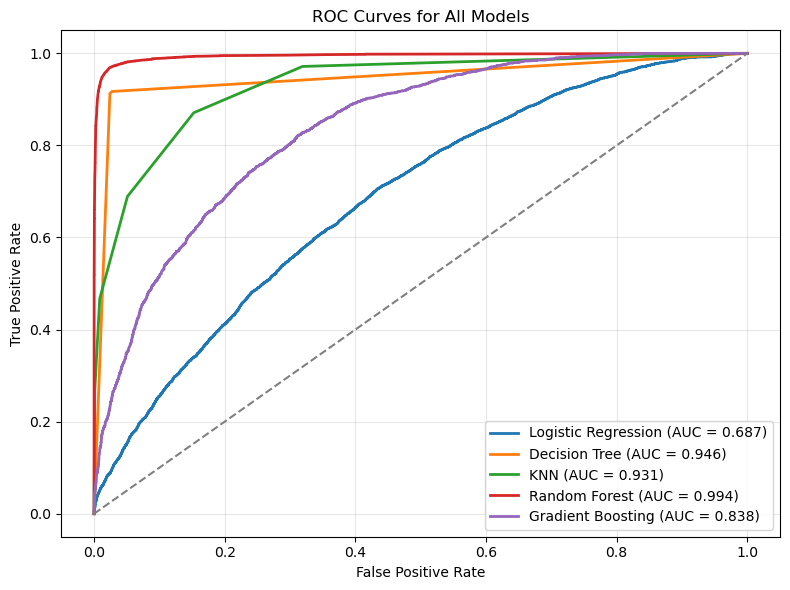

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, clf in models.items():
    y_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# 🔽 Save as JPEG
plt.savefig("roc_curves_cricket.jpeg", format='jpeg', dpi=300)

# Show the plot
plt.show()


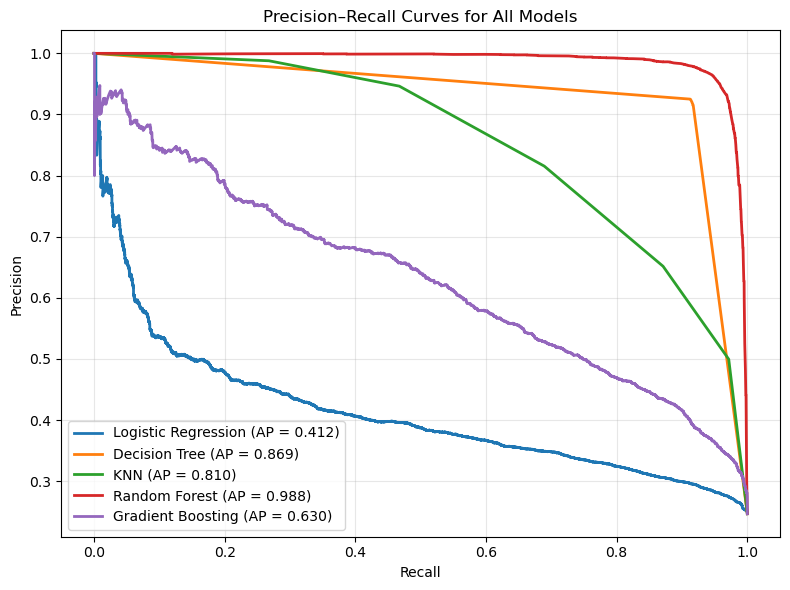

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for name, clf in models.items():
    y_proba = clf.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_prec = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, lw=2,
             label=f"{name} (AP = {avg_prec:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for All Models")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

# 🔽 Save as JPEG
plt.savefig("precision_recall_curves_cricket.jpeg", format='jpeg', dpi=300)

# Show the plot
plt.show()


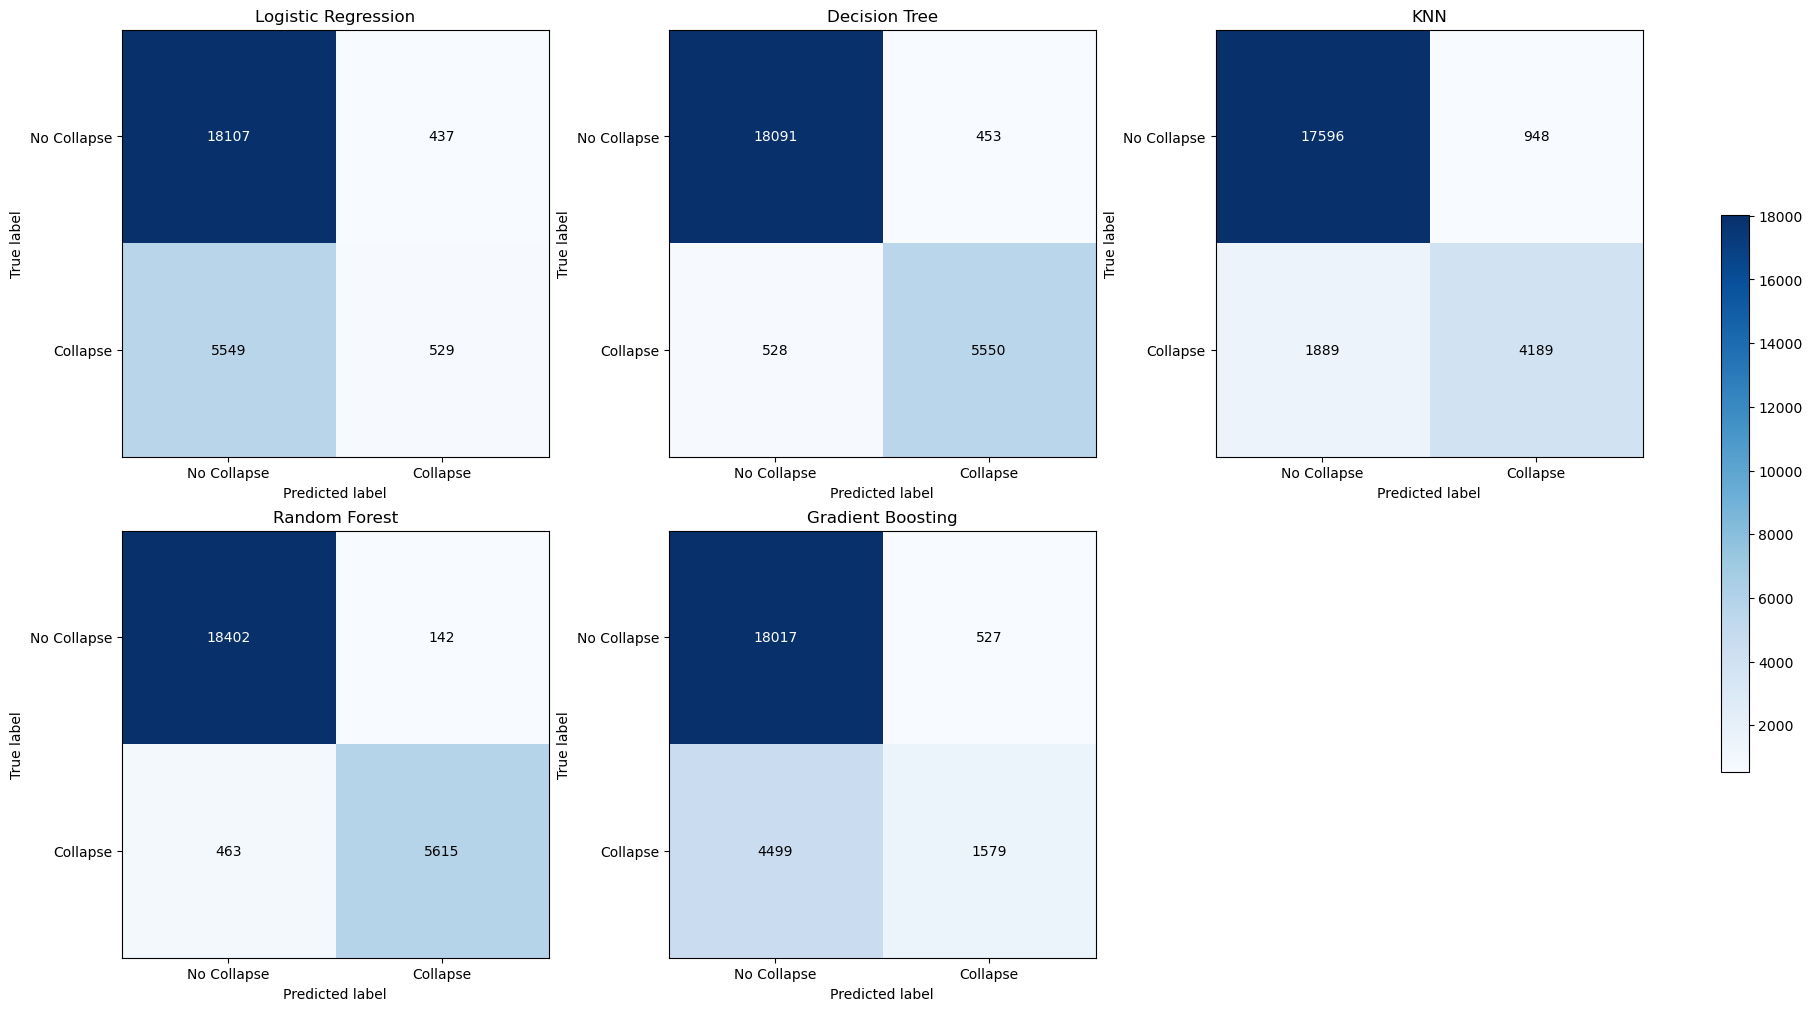

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Example setup: works with any number of models
n_models = len(models)

# Create custom layout: 2 rows × 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

for idx, (name, clf) in enumerate(models.items()):
    ax = axes[idx]
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Collapse', 'Collapse'])
    ax.set_yticklabels(['No Collapse', 'Collapse'])

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# Remove any unused subplot axes (e.g., 6th box if only 5 models)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

# Colorbar
fig.colorbar(im, ax=axes[:n_models], shrink=0.6)

# Save to JPEG
plt.savefig("confusion_matrices_cricket.jpeg", format='jpeg', dpi=300)
plt.show()


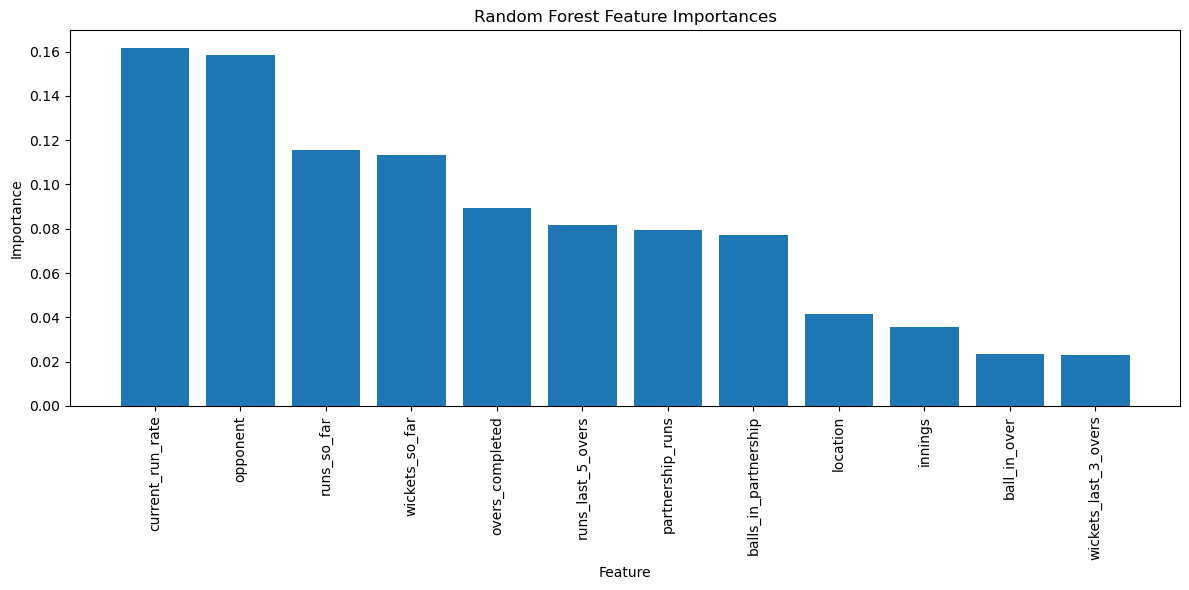

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the trained Random Forest
rf = models["Random Forest"]

# Get feature importances and feature names
importances = rf.feature_importances_
features = X.columns.to_list()

# Sort features by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()

# 🔽 Save as JPEG
plt.savefig("random_forest_feature_importance_cricket.jpeg", format='jpeg', dpi=300)

plt.show()


In [40]:
import shap
shap.initjs()

In [46]:

# 1. Fit the Random Forest on the full training data
rf = models["Random Forest"]
rf.fit(X_train, y_train)

# 3. Create a TreeExplainer and compute SHAP values on your test set
explainer = shap.TreeExplainer(rf)
# For binary classification, shap_values is a list: [array_for_class_0, array_for_class_1]
shap_values = explainer.shap_values(X_test)

# 4. Inspect the shape to confirm
print("SHAP values for positive class shape:", shap_values[1].shape)
print("X_test shape:", X_test.shape)


SHAP values for positive class shape: (12, 2)
X_test shape: (24622, 12)


In [52]:
print("SHAP Values Shape:", np.array(shap_values).shape)
print("X_test Shape:", X_test.shape)

SHAP Values Shape: (24622, 12, 2)
X_test Shape: (24622, 12)


In [54]:
shap_values_class_1 = shap_values[:, :, 1] 

In [58]:
# SHAP summary plot
shap.summary_plot(shap_values_class_1, X_test, feature_names=X_test.columns, show=False)

# Save current figure as JPEG
plt.savefig("shap_summary_plot_cricket.jpeg", format='jpeg', bbox_inches='tight', dpi=300)
plt.close()

In [62]:
# 1. Create a new figure (optional: adjust size)
plt.figure(figsize=(10, 6))

# 2. Draw the bar plot without showing it immediately
shap.plots.bar(shap_explanation, show=False)

# 3. Save the current figure to a JPEG file
plt.savefig("shap_bar_plot_cricket.jpeg",
            format="jpeg",
            dpi=300,              # adjust resolution as needed
            bbox_inches="tight")  # trim extra whitespace

# 4. (Optional) Close the figure if you’re in a script/notebook
plt.close()

In [64]:
# 1. Create a new figure (optional: adjust size)
plt.figure(figsize=(12, 8))

# 2. Draw the beeswarm plot without showing it interactively
shap.plots.beeswarm(shap_explanation, show=False)

# 3. Save to a JPEG file
plt.savefig(
    "shap_beeswarm_plot_cricket.jpeg",
    format="jpeg",
    dpi=300,              # high resolution
    bbox_inches="tight"   # trim whitespace
)

# 4. Close the figure (especially important in scripts)
plt.close()

In [78]:
instance_index = 0
shap_explanation = shap.Explanation(values=shap_values_class_1[instance_index], 
                                    base_values=explainer.expected_value[1],  # Expected value for class 1
                                    data=X_test.iloc[instance_index],
                                    feature_names=X_test.columns)
#shap.waterfall_plot(shap_explanation)

# 1. Create a new figure (adjust size as needed)
plt.figure(figsize=(10, 6))

# 2. Draw the waterfall plot without immediately showing it
shap.waterfall_plot(shap_explanation, show=False)

# 3. Save to a JPEG file
plt.savefig(
    "shap_waterfall_plot_cricket_1st.jpeg",
    format="jpeg",
    dpi=300,              # high resolution
    bbox_inches="tight"   # trim extra whitespace
)

# 4. Close the figure (important in scripts/notebooks to free memory)
plt.close()


In [82]:
# 1. Create a new figure (adjust size as needed)
plt.figure(figsize=(12, 4))

# 2. Draw the force plot as a static matplotlib plot
shap.plots.force(shap_explanation, matplotlib=True, show=False)

# 3. Save to a JPEG file
plt.savefig(
    "shap_force_plot_cricket.jpeg",
    format="jpeg",
    dpi=300,              # high resolution
    bbox_inches="tight"   # trim extra whitespace
)

# 4. Close the figure
plt.close()

In [84]:
# 5️⃣ Extract SHAP values for Class 1
shap_values_class_1 = shap_values[:, :, 1]  # Directly access NumPy array without `.values`

# 6️⃣ Compute Mean Absolute SHAP Values for Feature Importance
importance = np.abs(shap_values_class_1).mean(axis=0)  # Mean SHAP values per feature
feature_names = X_test.columns

<Figure size 1200x400 with 0 Axes>

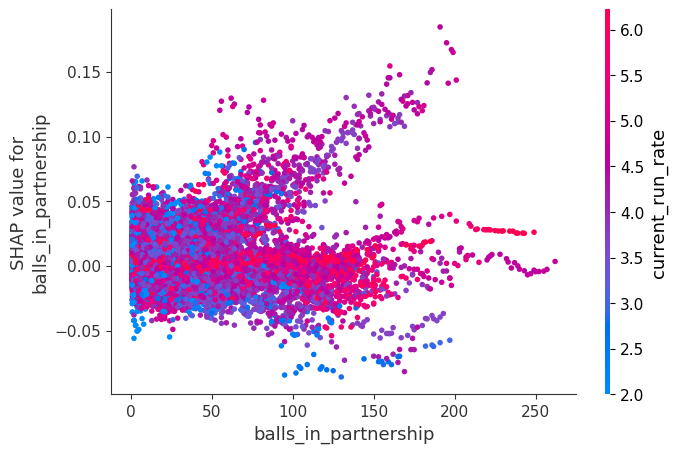

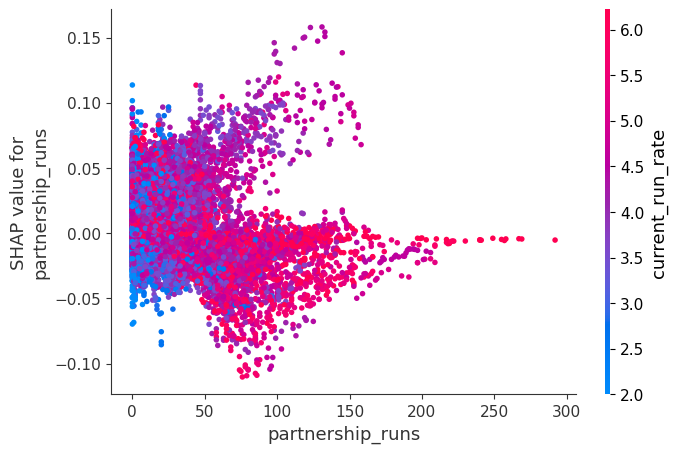

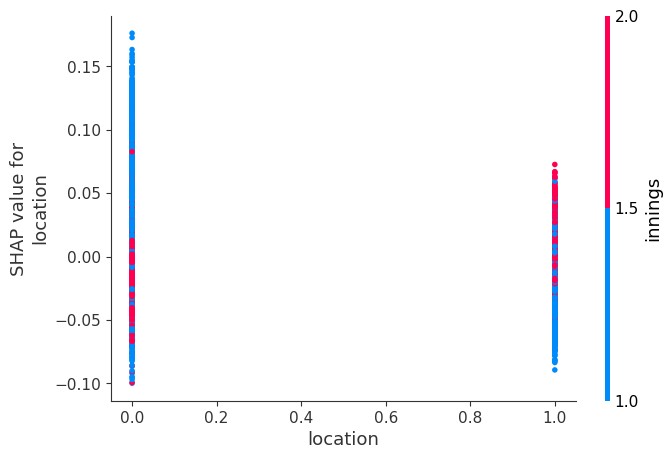

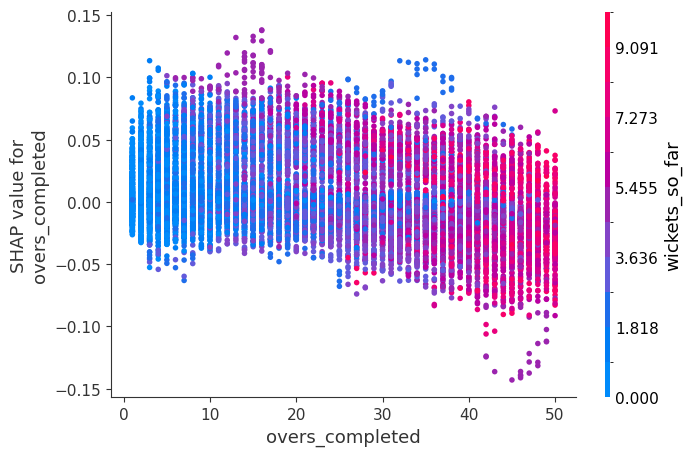

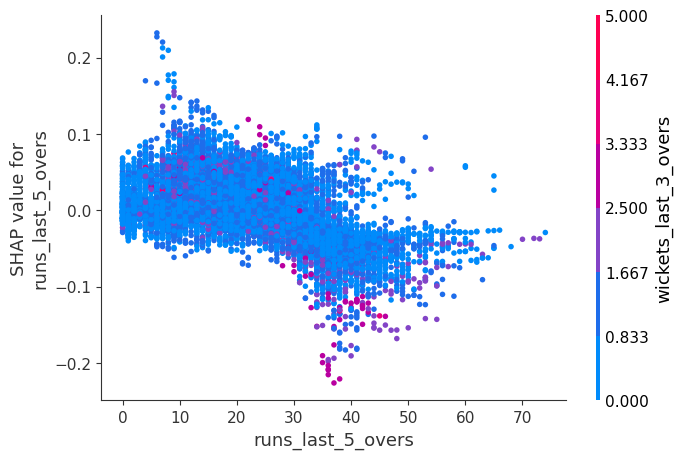

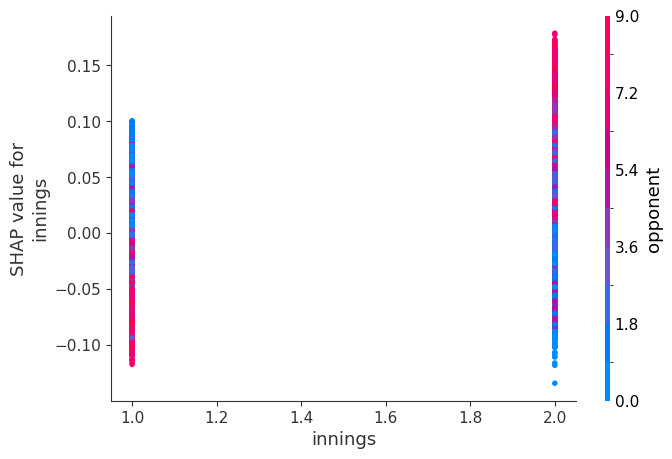

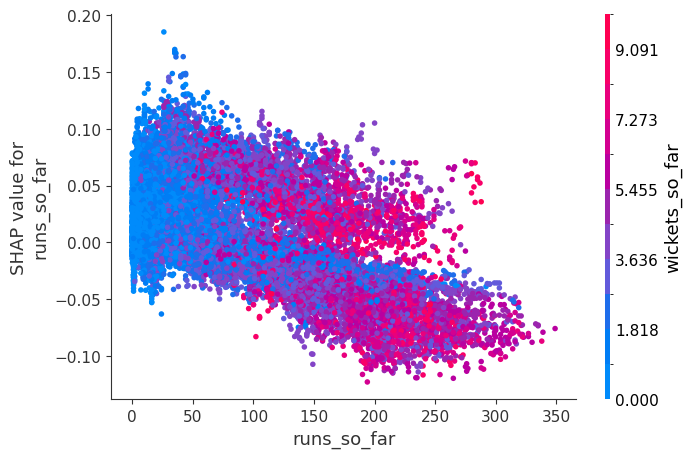

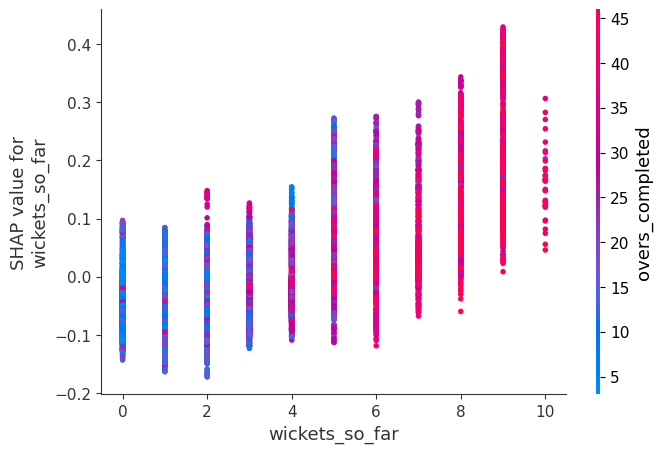

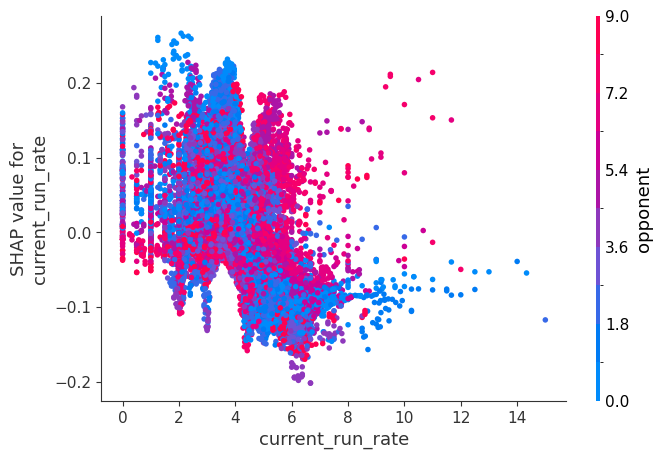

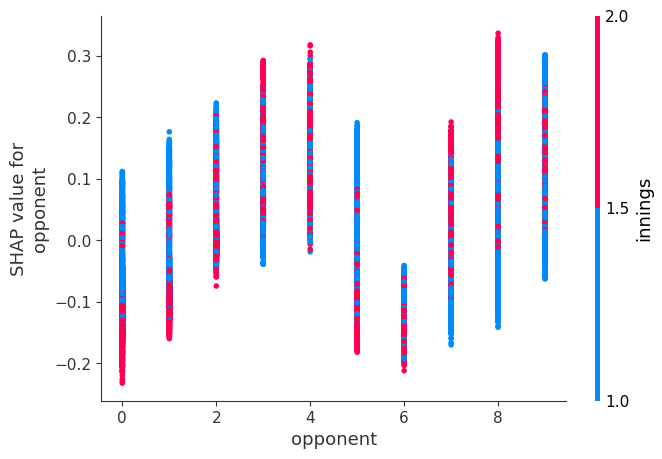

In [86]:
# 7️⃣ Get Indices of Top 4 Important Features
top_features = np.argsort(importance)[-10:]  # Top 10 feature indices

# 8️⃣ Plot SHAP Dependency Plots for Top 10 Features
for feature_idx in top_features:
    feature_name = feature_names[feature_idx]
    shap.dependence_plot(feature_name, shap_values_class_1, X_test)

In [88]:
# 7️⃣ Get Indices of Top 10 Important Features
top_features = np.argsort(importance)[-10:]  # Top 10 feature indices

# 8️⃣ Loop and save each SHAP dependence plot
for feature_idx in top_features:
    feature_name = feature_names[feature_idx]
    
    # 1. Start a new figure (size tweakable)
    plt.figure(figsize=(8, 6))
    
    # 2. Draw the dependence plot without auto-showing
    shap.dependence_plot(
        feature_name,
        shap_values_class_1,
        X_test,
        show=False
    )
    
    # 3. Save it to JPEG
    filename = f"shap_dependence_{feature_name}_cricket.jpeg"
    plt.savefig(
        filename,
        format="jpeg",
        dpi=300,
        bbox_inches="tight"
    )
    
    # 4. Close the figure to free memory
    plt.close()